Chargement des données...
Extraction des features avec TF-IDF...
Entraînement de la Régression Logistique...

--- ÉVALUATION SUR LE SET DE VALIDATION ---
Validation Macro F1-score: 0.9218

--- ÉVALUATION SUR LE SET DE TEST ---
Test Macro F1-score: 0.8987

Rapport de classification détaillé (Test) :
                      precision    recall  f1-score   support

Billing and Payments       0.84      0.81      0.82       131
     Feature Request       0.97      1.00      0.99       102
             Support       0.88      0.89      0.89       209

            accuracy                           0.89       442
           macro avg       0.90      0.90      0.90       442
        weighted avg       0.89      0.89      0.89       442

Matrice de confusion sauvegardée dans 'docs/images/baseline_confusion_matrix.png'.


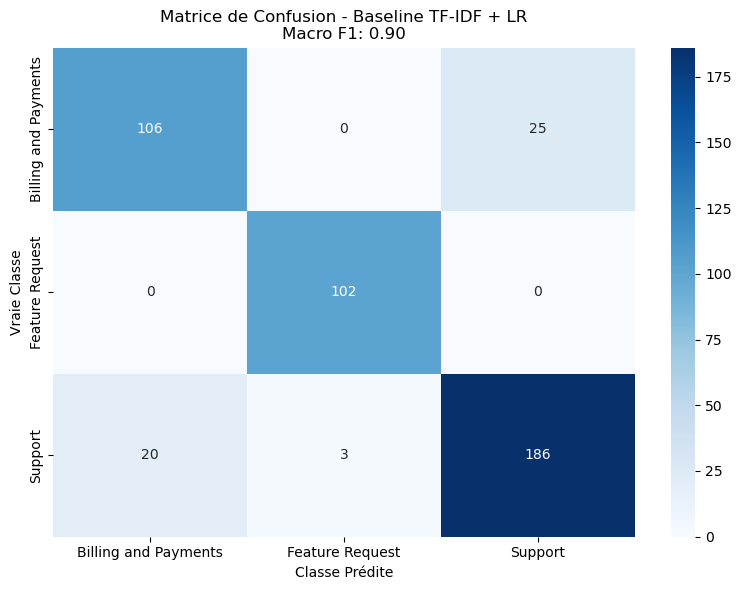

In [1]:

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. CHARGEMENT DES DONNÉES (Split d'Arthur)
# ==========================================
print("Chargement des données...")
train_df = pd.read_csv('data/train.csv')
val_df = pd.read_csv('data/val.csv')
test_df = pd.read_csv('data/test.csv')

# Séparation des features (X) et labels (y)
X_train, y_train = train_df['text'].fillna(""), train_df['label']
X_val, y_val = val_df['text'].fillna(""), val_df['label']
X_test, y_test = test_df['text'].fillna(""), test_df['label']

# ==========================================
# 2. VECTORISATION TF-IDF
# ==========================================
print("Extraction des features avec TF-IDF...")
# Extraction des unigrammes et bigrammes, en ignorant les mots vides (stopwords)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

# ==========================================
# 3. ENTRAÎNEMENT DE LA RÉGRESSION LOGISTIQUE
# ==========================================
print("Entraînement de la Régression Logistique...")
# class_weight='balanced' permet de gérer le déséquilibre des classes observé lors de l'EDA
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_tfidf, y_train)

# ==========================================
# 4. ÉVALUATION (Validation & Test)
# ==========================================
print("\n--- ÉVALUATION SUR LE SET DE VALIDATION ---")
y_val_pred = model.predict(X_val_tfidf)
val_macro_f1 = f1_score(y_val, y_val_pred, average='macro')
print(f"Validation Macro F1-score: {val_macro_f1:.4f}")

print("\n--- ÉVALUATION SUR LE SET DE TEST ---")
y_test_pred = model.predict(X_test_tfidf)
test_macro_f1 = f1_score(y_test, y_test_pred, average='macro')
print(f"Test Macro F1-score: {test_macro_f1:.4f}")

print("\nRapport de classification détaillé (Test) :")
print(classification_report(y_test, y_test_pred))

# ==========================================
# 5. MATRICE DE CONFUSION
# ==========================================
cm = confusion_matrix(y_test, y_test_pred, labels=model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title(f'Matrice de Confusion - Baseline TF-IDF + LR\nMacro F1: {test_macro_f1:.2f}')
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.tight_layout()
plt.savefig('docs/images/baseline_confusion_matrix.png')
print("Matrice de confusion sauvegardée dans 'docs/images/baseline_confusion_matrix.png'.")


